# Restaurant Dataset — Preprocessing & Feature Engineering

**Course:** Business Analytics
**Dataset:** `restaurants_10000.csv` (Bengaluru restaurants scraped listing)
**Author:** Poojitha D.

The notebook is organised into the following sections:

1. Dataset Analysis (understand what we're working with)
2. Row Filtering (drop rows with zero reviews)
3. Price Column Cleaning
4. Target Column Creation (`High Rated`)
5. Feature Engineering from the `Features` text column
6. Validation of Engineered Features
7. Missing Value Recheck
8. Duplicate Check
9. Final Dataset Summary
10. Saving the Cleaned Dataset


In [1]:
# Core libraries used throughout the notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 150)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print("Libraries imported successfully.")


Libraries imported successfully.


## 1. Dataset Analysis



In [3]:
# Load the raw dataset
df_raw = pd.read_csv('Downloads/restaurants_10000.csv')


df = df_raw.copy()

print("Shape of dataset:", df.shape)


Shape of dataset: (10164, 24)


In [3]:
# First 5 rows
df.head()


,title,categoryName,description,price,totalScore,reviewsCount,imagesCount,address,neighborhood,street,city,postalCode,state,website,phone,location.lat,location.lng,openingHours,reviewsDistribution.oneStar,reviewsDistribution.twoStar,reviewsDistribution.threeStar,reviewsDistribution.fourStar,reviewsDistribution.fiveStar,Features
0,080 International Lounge - Bangalore Airport,International,NaN,NaN,3.5,3.0,NaN,Kempegowda International Airport Bengaluru Lev...,Kempegowda International Airport Bengaluru Lev...,Kempegowda International Airport Bengaluru Lev...,Bengaluru,560300,Karnataka,NaN,+91 86575 41678,13.070601,77.791855,NaN,NaN,NaN,NaN,NaN,NaN,
1,1 Bar House Kitchen (1BHK),Restaurant,NaN,"₹600–1,800",4.3,3401.0,3196.0,"56, Raj villa, 5th cross, 60 Feet Rd, 6th Bloc...","KHB Colony, 6th Block, Koramangala","56, Raj villa, 5th cross, 60 Feet Rd",Bengaluru,560095.0,Karnataka,NaN,+91 95914 26566,12.936549,77.621132,"[{'day': 'Monday', 'hours': '12 to 11:45\u202f...",142.0,102.0,251.0,905.0,2001.0,Accepts reservations | Alcohol | All you can e...
2,"1 By 2, Veg Restaurant",,NaN,NaN,3.0,1.0,NaN,"67 8'th Main Road Vasanthnagar, Bengaluru 5600...",67 8'th Main Road Vasanthnagar,67 8'th Main Road Vasanthnagar,Bengaluru,560052,Karnataka,NaN,+91 97407 12746,13.058670,77.565420,NaN,NaN,NaN,NaN,NaN,NaN,
3,10 Speakeasy,,NaN,NaN,NaN,0.0,NaN,"10 Wood Street, Bengaluru 560025 India",10 Wood Street,10 Wood Street,Bengaluru,560025,Karnataka,NaN,+91 96060 69006,12.967143,77.608444,NaN,NaN,NaN,NaN,NaN,NaN,
4,100 ft,Italian Mediterranean,NaN,NaN,4.0,112.0,NaN,"777/I 100 Ft Road, Bengaluru 560038 India",777/I 100 Ft Road,777/I 100 Ft Road,Bengaluru,560038,Karnataka,NaN,+91 98864 88439,12.879450,77.559670,NaN,NaN,NaN,NaN,NaN,NaN,Reservations Seating Parking Available Serves ...


In [4]:
# Last 5 rows
df.tail()


,title,categoryName,description,price,totalScore,reviewsCount,imagesCount,address,neighborhood,street,city,postalCode,state,website,phone,location.lat,location.lng,openingHours,reviewsDistribution.oneStar,reviewsDistribution.twoStar,reviewsDistribution.threeStar,reviewsDistribution.fourStar,reviewsDistribution.fiveStar,Features
10159,the malayali kitchen,South Indian restaurant,NaN,₹1–200,3.9,206.0,101.0,"1st cross, Kodihalli Main Rd, behind big pictu...","HAL 2nd Stage, Kodihalli","1st cross, Kodihalli Main Rd, behind big picture",Bengaluru,560008.0,Karnataka,NaN,+91 75939 09000,12.960621,77.646915,"[{'day': 'Monday', 'hours': '12:30 to 10:30\u2...",37.0,4.0,17.0,27.0,121.0,Assistive hearing loop | Breakfast | Brunch | ...
10160,thoda aur,Northern-Italian,NaN,NaN,5.0,1.0,NaN,"1016, 80 Feet Main Road, Koramangala 1st Block...",Koramangala 1st Block Wipro Signal,1016,Bengaluru,560034,Karnataka,NaN,NaN,12.930343,77.633200,NaN,NaN,NaN,NaN,NaN,NaN,Delivery Takeout Seating Street Parking Digita...
10161,vijayanagar,Indian,NaN,NaN,4.5,3.0,NaN,"52/2 17'th Cross Road, Bengaluru 560040 India",52/2 17'th Cross Road,52/2 17'th Cross Road,Bengaluru,560040,Karnataka,NaN,+91 98865 10405,12.970290,77.529960,NaN,NaN,NaN,NaN,NaN,NaN,
10162,zaatar Bengaluru,Chinese Indian Asian Arabic,NaN,NaN,3.0,13.0,NaN,"Old Madras Road, Bengaluru 560016 India",Old Madras Road,Old Madras Road,Bengaluru,560016,Karnataka,NaN,+91 80 4854 2124,12.983300,77.583300,NaN,NaN,NaN,NaN,NaN,NaN,Reservations Seating Table Service ...
10163,ನ್ಯೂ ಉಡುಪಿ ಗ್ರಾಂಡ್ | New Udupi Grand,South Indian restaurant,NaN,NaN,3.9,1115.0,160.0,"Shop No: 35, Jayanagar, Kaveramma Temple Steet...","1st Block East, 1st Block, Hombegowda Nagar","Shop No: 35, Jayanagar, Kaveramma Temple Steet",Bengaluru,560011.0,Karnataka,NaN,+91 80508 27848,12.935416,77.592620,"[{'day': 'Monday', 'hours': '6:30\u202fAM to 1...",104.0,55.0,192.0,316.0,448.0,NaN


In [5]:
# Data types of every column
df.dtypes


title                                str
categoryName                         str
description                          str
price                                str
totalScore                       float64
reviewsCount                     float64
imagesCount                      float64
address                              str
neighborhood                         str
street                               str
city                                 str
postalCode                           str
state                                str
website                              str
phone                                str
location.lat                     float64
location.lng                     float64
openingHours                         str
reviewsDistribution.oneStar      float64
reviewsDistribution.twoStar      float64
reviewsDistribution.threeStar    float64
reviewsDistribution.fourStar     float64
reviewsDistribution.fiveStar     float64
Features                             str
dtype: object

In [6]:
# Missing values per column
df.isnull().sum()


title                               0
categoryName                        0
description                      9129
price                            3359
totalScore                       3829
reviewsCount                       19
imagesCount                      9291
address                             0
neighborhood                      122
street                             19
city                                0
postalCode                       1238
state                               0
website                          3576
phone                             828
location.lat                      329
location.lng                      329
openingHours                     9291
reviewsDistribution.oneStar      3139
reviewsDistribution.twoStar      3139
reviewsDistribution.threeStar    3139
reviewsDistribution.fourStar     3139
reviewsDistribution.fiveStar     3139
Features                           21
dtype: int64

In [7]:
# Duplicate rows (exact duplicates across all columns)
print("Number of fully duplicated rows:", df.duplicated().sum())


Number of fully duplicated rows: 0


In [8]:
# Number of unique values per column - helps spot ID-like columns vs categorical ones
df.nunique().sort_values(ascending=False)


address                          10008
phone                             8402
street                            8330
title                             8127
location.lat                      6808
location.lng                      6373
neighborhood                      6087
website                           3170
Features                          1605
categoryName                      1026
description                        951
reviewsCount                       752
reviewsDistribution.fiveStar       566
imagesCount                        513
reviewsDistribution.fourStar       428
openingHours                       334
reviewsDistribution.threeStar      325
reviewsDistribution.oneStar        287
postalCode                         249
reviewsDistribution.twoStar        210
price                               37
totalScore                          35
city                                 8
state                                1
dtype: int64

In [9]:
# Summary statistics for numeric columns
df.describe()


,totalScore,reviewsCount,imagesCount,location.lat,location.lng,reviewsDistribution.oneStar,reviewsDistribution.twoStar,reviewsDistribution.threeStar,reviewsDistribution.fourStar,reviewsDistribution.fiveStar
count,6335.000000,10145.000000,873.000000,9835.000000,9835.000000,7025.000000,7025.000000,7025.000000,7025.000000,7025.000000
mean,3.977316,173.461212,835.970218,12.976215,77.610934,17.090819,8.861068,26.455943,64.629609,136.757153
std,0.641961,1403.076933,2545.419934,0.496814,0.759069,88.109674,49.408475,156.587163,447.451552,987.005507
min,1.000000,0.000000,0.000000,7.824931,13.095110,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.500000,0.000000,32.000000,12.927370,77.578205,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.000000,1.000000,149.000000,12.964420,77.608430,0.000000,0.000000,1.000000,2.000000,1.000000
75%,4.500000,7.000000,665.000000,12.990130,77.642860,2.000000,1.000000,4.000000,7.000000,6.000000
max,5.000000,62149.000000,44531.000000,41.834774,102.851685,2430.000000,1268.000000,4027.000000,17681.000000,38515.000000


In [4]:
# Column names
list(df.columns)


['title',
 'categoryName',
 'description',
 'price',
 'totalScore',
 'reviewsCount',
 'imagesCount',
 'address',
 'neighborhood',
 'street',
 'city',
 'postalCode',
 'state',
 'website',
 'phone',
 'location.lat',
 'location.lng',
 'openingHours',
 'reviewsDistribution.oneStar',
 'reviewsDistribution.twoStar',
 'reviewsDistribution.threeStar',
 'reviewsDistribution.fourStar',
 'reviewsDistribution.fiveStar',
 'Features']

### Column meanings (based on inspection of the raw data)

| Column | Meaning |
|---|---|
| `title` | Name of the restaurant |
| `categoryName` | Cuisine / category tag (e.g. "Restaurant", "International") |
| `description` | Free-text description (mostly empty) |
| `price` | Price range as text, e.g. `₹200–400` |
| `totalScore` | Average rating out of 5 (this is our "Rating") |
| `reviewsCount` | Number of reviews the restaurant has received |
| `imagesCount` | Number of photos uploaded for the listing |
| `address` / `neighborhood` / `street` / `city` / `postalCode` / `state` | Location fields |
| `website` / `phone` | Contact info |
| `location.lat` / `location.lng` | GPS coordinates |
| `openingHours` | Opening hours, stored as a string that looks like a list of dicts |
| `reviewsDistribution.*` | Breakdown of how many 1-star, 2-star ... 5-star reviews exist |
| `Features` | Free-text, pipe/space separated list of amenities (parking, delivery, etc.) |

Two columns line up with the terms the project brief uses:
- **"Rating"** in the brief → `totalScore` in this dataset
- **"Reviews Count"** in the brief → `reviewsCount` in this dataset
- **"Price"** in the brief → `price` in this dataset

These mappings are used throughout the rest of the notebook.


In [11]:
# Classify columns by type for our own reference

numerical_cols = ['totalScore', 'reviewsCount', 'imagesCount',
                   'location.lat', 'location.lng',
                   'reviewsDistribution.oneStar', 'reviewsDistribution.twoStar',
                   'reviewsDistribution.threeStar', 'reviewsDistribution.fourStar',
                   'reviewsDistribution.fiveStar']

categorical_cols = ['categoryName', 'city', 'state', 'postalCode']

text_cols = ['title', 'description', 'address', 'neighborhood', 'street',
             'website', 'phone', 'openingHours', 'Features', 'price']

print("Numerical columns:", numerical_cols)
print()
print("Categorical columns:", categorical_cols)
print()
print("Text / semi-structured columns:", text_cols)


Numerical columns: ['totalScore', 'reviewsCount', 'imagesCount', 'location.lat', 'location.lng', 'reviewsDistribution.oneStar', 'reviewsDistribution.twoStar', 'reviewsDistribution.threeStar', 'reviewsDistribution.fourStar', 'reviewsDistribution.fiveStar']

Categorical columns: ['categoryName', 'city', 'state', 'postalCode']

Text / semi-structured columns: ['title', 'description', 'address', 'neighborhood', 'street', 'website', 'phone', 'openingHours', 'Features', 'price']


### Obvious inconsistencies 

- `price` is stored as text like `₹600–1,800` (currency symbol, en-dash range,
  and thousands-comma all mixed in) rather than as a clean number.
- `categoryName` sometimes contains just blank spaces (`'        '`) instead of
  a real value or `NaN`.
- `Features` is a free-text pipe-separated (or plain space-separated) list, so
  it isn't directly usable as a categorical column - it needs to be exploded
  into binary flags.
- `reviewsCount == 0` rows exist - restaurants with zero reviews carry no
  useful rating signal, so the brief asks us to drop these.
- `openingHours` is a string that *looks* like a Python list of dicts (it was
  probably serialized directly from JSON), not something pandas parses natively.


In [12]:
# Percentage of missing values per column, sorted descending
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
missing_pct


imagesCount                      91.410862
openingHours                     91.410862
description                      89.817001
totalScore                       37.672176
website                          35.182999
price                            33.048013
reviewsDistribution.twoStar      30.883510
reviewsDistribution.fourStar     30.883510
reviewsDistribution.threeStar    30.883510
reviewsDistribution.fiveStar     30.883510
reviewsDistribution.oneStar      30.883510
postalCode                       12.180244
phone                             8.146399
location.lat                      3.236915
location.lng                      3.236915
neighborhood                      1.200315
Features                          0.206612
street                            0.186934
reviewsCount                      0.186934
dtype: float64

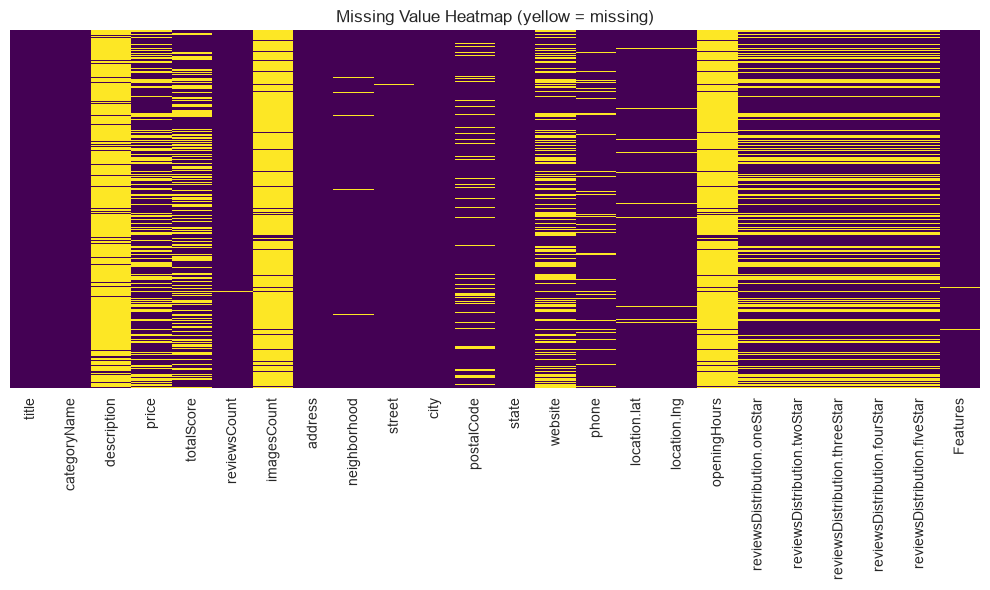

In [5]:
# Missing value heatmap 
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Value Heatmap (yellow = missing)')
plt.tight_layout()
plt.show()


## 2. Step 1 — Remove Rows With No Reviews

A restaurant with `reviewsCount == 0` has no rating signal at all (in fact,
`totalScore` is almost always missing for these rows too), so they add noise
rather than information. We drop them.


In [14]:
rows_before = df.shape[0]

# Some reviewsCount values are themselves missing - treat those the same way
# as 0, since "unknown number of reviews" is just as useless for our purpose
df = df[df['reviewsCount'].fillna(0) > 0].copy()

rows_after = df.shape[0]

print("Rows before:", rows_before)
print("Rows after :", rows_after)
print("Rows removed:", rows_before - rows_after)


Rows before: 10164
Rows after : 6335
Rows removed: 3829


## 3. Step 2 — Handle the `price` Column

### 3.1 


In [15]:
print("Current dtype of price:", df['price'].dtype)
print()
print("A sample of raw values:")
df['price'].dropna().sample(10, random_state=42)


Current dtype of price: str

A sample of raw values:


2602    ₹200–400
4415    ₹200–400
8651    ₹400–600
8153    ₹600–800
8103    ₹400–600
596     ₹200–600
7857    ₹200–400
5145    ₹600–800
7606    ₹200–400
2053    ₹200–400
Name: price, dtype: str

In [16]:
def clean_price_range(value):
    """Convert a price-range string like '₹600-1,800' or '₹2,000+' into a
    single numeric value (the midpoint of the range).

    Handles:
    - missing values (NaN) -> NaN
    - the rupee symbol
    - thousands separators (commas)
    - both the en-dash (–) and hyphen (-) as range separators
    - an open-ended '+' range (e.g. '₹2,000+') -> just the lower bound
    """
    if pd.isna(value):
        return np.nan

    text = str(value).strip()
    if text == '' or text.lower() == 'nan':
        return np.nan

    # remove currency symbol and commas
    text = text.replace('\u20b9', '').replace(',', '').strip()

    # open-ended range like "2000+"
    if text.endswith('+'):
        try:
            return float(text[:-1])
        except ValueError:
            return np.nan

    # normalise the different dash characters that show up in scraped text
    text = text.replace('\u2013', '-').replace('\u2014', '-')

    if '-' in text:
        parts = [p.strip() for p in text.split('-') if p.strip() != '']
        try:
            numbers = [float(p) for p in parts]
            return sum(numbers) / len(numbers)
        except ValueError:
            return np.nan

    # single number, no range
    try:
        return float(text)
    except ValueError:
        return np.nan


# Apply the cleaning function and store the result in a new numeric column
df['price_numeric'] = df['price'].apply(clean_price_range)

print("Missing values in price (raw text):", df['price'].isnull().sum())
print("Missing values in price_numeric   :", df['price_numeric'].isnull().sum())
df[['price', 'price_numeric']].head(10)


Missing values in price (raw text): 1616
Missing values in price_numeric   : 1622


,price,price_numeric
0,NaN,NaN
1,"₹600–1,800",1200.0
2,NaN,NaN
4,NaN,NaN
5,₹600–800,700.0
8,₹400–600,500.0
9,"₹800–1,000",900.0
10,₹200–400,300.0
11,NaN,NaN
12,₹600–800,700.0


### 3.2 Detect extreme values (outliers) 




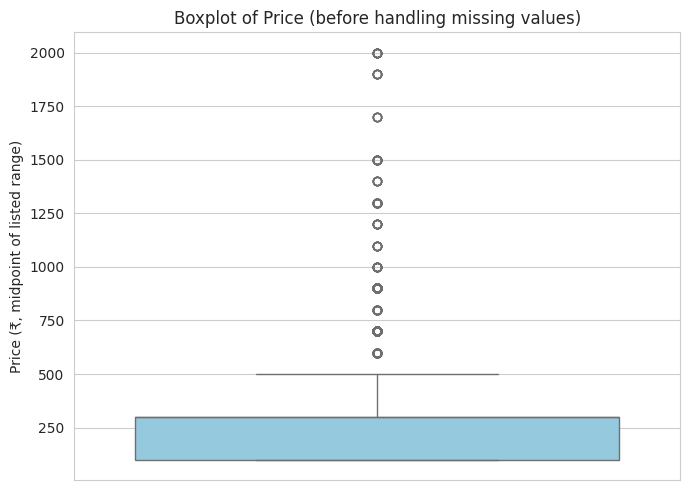

In [17]:
plt.figure(figsize=(7, 5))
sns.boxplot(y=df['price_numeric'], color='skyblue')
plt.title('Boxplot of Price (before handling missing values)')
plt.ylabel('Price (₹, midpoint of listed range)')
plt.tight_layout()
plt.show()


In [18]:
# IQR method for outlier detection
Q1 = df['price_numeric'].quantile(0.25)
Q3 = df['price_numeric'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['price_numeric'] < lower_bound) | (df['price_numeric'] > upper_bound)]

print(f"Q1 = {Q1}, Q3 = {Q3}, IQR = {IQR}")
print(f"Lower Bound = {lower_bound}")
print(f"Upper Bound = {upper_bound}")
print(f"Number of outliers detected = {outliers.shape[0]}")


Q1 = 100.5, Q3 = 300.0, IQR = 199.5
Lower Bound = -198.75
Upper Bound = 599.25
Number of outliers detected = 581


### 3.3 Fill missing prices using the median




In [19]:
missing_before = df['price_numeric'].isnull().sum()

median_price = df['price_numeric'].median()
print("Median price used for imputation: ₹", median_price)

df['price_numeric'] = df['price_numeric'].fillna(median_price)

missing_after = df['price_numeric'].isnull().sum()

print("Missing prices before imputation:", missing_before)
print("Missing prices after imputation :", missing_after)


Median price used for imputation: ₹ 300.0
Missing prices before imputation: 1622
Missing prices after imputation : 0


## 4. Step 3 — Create the `High Rated` Target Column




In [20]:
# Restaurants with a missing totalScore can't be labelled either way,
# so we only assign 1/0 where a score actually exists.
df['High Rated'] = np.where(df['totalScore'] >= 4.0, 1,
                     np.where(df['totalScore'].notna(), 0, np.nan))

print("Class distribution of 'High Rated':")
print(df['High Rated'].value_counts(dropna=False))
print()
print("As percentages:")
print(df['High Rated'].value_counts(normalize=True, dropna=False) * 100)


Class distribution of 'High Rated':


High Rated
1.0    4516
0.0    1819
Name: count, dtype: int64

As percentages:
High Rated
1.0    71.286504
0.0    28.713496
Name: proportion, dtype: float64


/tmp/ipykernel_575/3530192120.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['High Rated'].dropna(), palette='viridis')


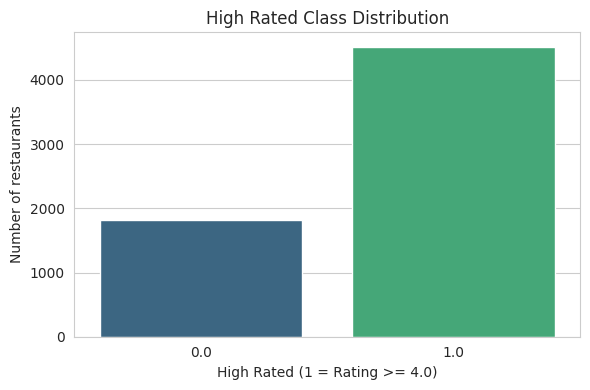

In [21]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df['High Rated'].dropna(), palette='viridis')
plt.title('High Rated Class Distribution')
plt.xlabel('High Rated (1 = Rating >= 4.0)')
plt.ylabel('Number of restaurants')
plt.tight_layout()
plt.show()


## 5. Step 4 — Feature Engineering From the `Features` Column



In [22]:
def has_any_keyword(text, keywords):
    """Return 1 if any keyword appears (case-insensitively) inside text,
    else 0. NaN-safe: a missing Features string just returns 0 for everything.
    """
    if pd.isna(text):
        return 0
    text_lower = str(text).lower()
    return int(any(keyword.lower() in text_lower for keyword in keywords))


# Keyword groups, one per engineered column, exactly as specified in the brief
feature_keyword_map = {
    'Reservations': ['reservation', 'reservations', 'reserve', 'booking', 'table reservation'],
    'Parking': ['parking', 'free parking', 'street parking', 'valet parking', 'parking available'],
    'Delivery': ['delivery', 'home delivery', 'online delivery', 'door delivery'],
    'Outdoor Seating': ['outdoor seating', 'seating', 'outdoor', 'open air seating'],
    'Takeout': ['takeout', 'take away', 'takeaway', 'pickup', 'pick-up'],
    'Vegetarian Options': ['vegetarian', 'veg', 'vegan', 'pure veg', 'plant based'],
    'Wheelchair Accessible': ['wheelchair', 'accessible', 'disabled access'],
    'Family Friendly': ['family', 'kids', 'child friendly'],
    'Pet Friendly': ['pet friendly', 'pets allowed', 'dogs allowed'],
}

for new_col, keywords in feature_keyword_map.items():
    df[new_col] = df['Features'].apply(lambda x: has_any_keyword(x, keywords))

print("New binary feature columns created:")
print(list(feature_keyword_map.keys()))


New binary feature columns created:
['Reservations', 'Parking', 'Delivery', 'Outdoor Seating', 'Takeout', 'Vegetarian Options', 'Wheelchair Accessible', 'Family Friendly', 'Pet Friendly']


In [23]:
df[['Features'] + list(feature_keyword_map.keys())].head(10)


,Features,Reservations,Parking,Delivery,Outdoor Seating,Takeout,Vegetarian Options,Wheelchair Accessible,Family Friendly,Pet Friendly
0,,0,0,0,0,0,0,0,0,0
1,Accepts reservations | Alcohol | All you can e...,1,1,1,1,1,1,1,1,0
2,,0,0,0,0,0,0,0,0,0
4,Reservations Seating Parking Available Serves ...,1,1,0,1,0,0,0,0,0
5,Reservations Seating Serves Alcohol Table Serv...,1,0,0,1,0,0,0,0,0
8,Accepts reservations | Casual | Cozy | Credit ...,1,1,1,0,1,0,0,1,0
9,Reservations Outdoor Seating Buffet Seating Pa...,1,1,0,1,0,0,1,0,0
10,Delivery Takeout Seating Digital Payments Free...,0,0,1,1,1,0,0,0,0
11,Seating Live Music,0,0,0,1,0,0,0,0,0
12,Reservations Outdoor Seating Seating Table Ser...,1,0,0,1,0,0,0,0,0


## 6. Step 5 — Validate the Engineered Features




In [24]:
for col in feature_keyword_map.keys():
    print(col)
    print(df[col].value_counts())
    print('-' * 30)


Reservations
Reservations
0    4864
1    1471
Name: count, dtype: int64
------------------------------
Parking
Parking
0    5076
1    1259
Name: count, dtype: int64
------------------------------
Delivery
Delivery
0    5193
1    1142
Name: count, dtype: int64
------------------------------
Outdoor Seating
Outdoor Seating
0    4640
1    1695
Name: count, dtype: int64
------------------------------
Takeout
Takeout
0    4800
1    1535
Name: count, dtype: int64
------------------------------
Vegetarian Options
Vegetarian Options
0    5901
1     434
Name: count, dtype: int64
------------------------------
Wheelchair Accessible
Wheelchair Accessible
0    5818
1     517
Name: count, dtype: int64
------------------------------
Family Friendly
Family Friendly
0    5533
1     802
Name: count, dtype: int64
------------------------------
Pet Friendly
Pet Friendly
0    6271
1      64
Name: count, dtype: int64
------------------------------


/tmp/ipykernel_575/1786897786.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_summary.values, y=feature_summary.index, palette='mako')


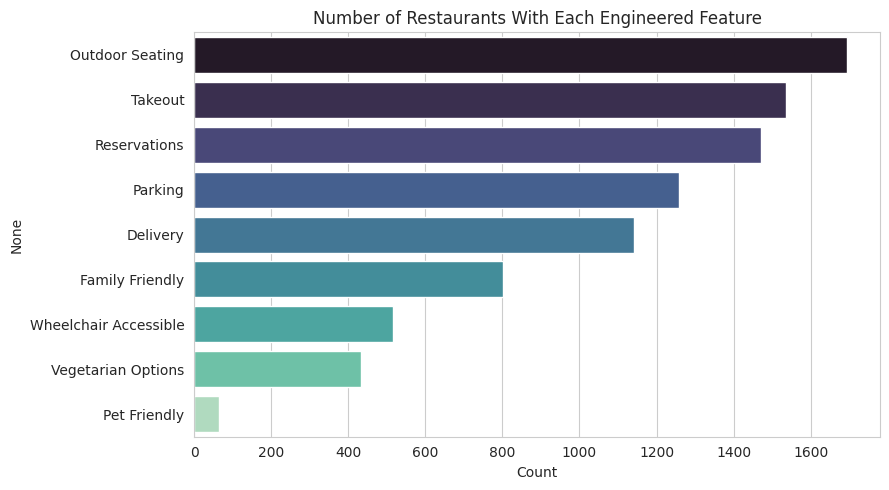

In [25]:
# Visualise all engineered feature columns together
feature_summary = df[list(feature_keyword_map.keys())].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=feature_summary.values, y=feature_summary.index, palette='mako')
plt.title('Number of Restaurants With Each Engineered Feature')
plt.xlabel('Count')
plt.tight_layout()
plt.show()


## 7. Step 6 — Missing Value Recheck




In [26]:
df.isnull().sum().sort_values(ascending=False)


description                      5549
openingHours                     5481
imagesCount                      5481
website                          1838
price                            1616
reviewsDistribution.fiveStar     1399
reviewsDistribution.fourStar     1399
reviewsDistribution.oneStar      1399
reviewsDistribution.twoStar      1399
reviewsDistribution.threeStar    1399
postalCode                        787
phone                             438
location.lng                      296
location.lat                      296
neighborhood                       76
Features                           19
street                             18
categoryName                        0
title                               0
state                               0
totalScore                          0
address                             0
city                                0
reviewsCount                        0
price_numeric                       0
High Rated                          0
Reservations

Remaining missing values, and what to do with them:

- `totalScore` / `High Rated`: still missing for a handful of restaurants that
  have reviews but no aggregate score recorded by the source. I
  leave these as `NaN` rather than guessing a rating.
- `description`, `website`, `openingHours`, `imagesCount`: high-missingness
  columns that are outside the scope of this feature-engineering pass. They
  are left untouched so nothing is lost.
- `neighborhood`, `street`, `postalCode`, `phone`, `location.lat/lng`: minor
  gaps in location metadata. Since they aren't used in any engineered feature
  here, they're left as-is.



## 8. Step 7 — Duplicate Check


In [27]:
duplicates_before = df.duplicated().sum()
print("Duplicate rows before:", duplicates_before)

df = df.drop_duplicates().copy()

duplicates_after = df.duplicated().sum()
print("Duplicate rows after :", duplicates_after)


Duplicate rows before: 0
Duplicate rows after : 0


## 9. Step 8 — Final Dataset Summary


In [28]:
print("Final Shape:", df.shape)


Final Shape: (6335, 35)


In [29]:
print("Final column list:")
list(df.columns)


Final column list:


['title',
 'categoryName',
 'description',
 'price',
 'totalScore',
 'reviewsCount',
 'imagesCount',
 'address',
 'neighborhood',
 'street',
 'city',
 'postalCode',
 'state',
 'website',
 'phone',
 'location.lat',
 'location.lng',
 'openingHours',
 'reviewsDistribution.oneStar',
 'reviewsDistribution.twoStar',
 'reviewsDistribution.threeStar',
 'reviewsDistribution.fourStar',
 'reviewsDistribution.fiveStar',
 'Features',
 'price_numeric',
 'High Rated',
 'Reservations',
 'Parking',
 'Delivery',
 'Outdoor Seating',
 'Takeout',
 'Vegetarian Options',
 'Wheelchair Accessible',
 'Family Friendly',
 'Pet Friendly']

In [30]:
df.dtypes


title                                str
categoryName                         str
description                          str
price                                str
totalScore                       float64
reviewsCount                     float64
imagesCount                      float64
address                              str
neighborhood                         str
street                               str
city                                 str
postalCode                           str
state                                str
website                              str
phone                                str
location.lat                     float64
location.lng                     float64
openingHours                         str
reviewsDistribution.oneStar      float64
reviewsDistribution.twoStar      float64
reviewsDistribution.threeStar    float64
reviewsDistribution.fourStar     float64
reviewsDistribution.fiveStar     float64
Features                             str
price_numeric   

In [31]:
df.isnull().sum()


title                               0
categoryName                        0
description                      5549
price                            1616
totalScore                          0
reviewsCount                        0
imagesCount                      5481
address                             0
neighborhood                       76
street                             18
city                                0
postalCode                        787
state                               0
website                          1838
phone                             438
location.lat                      296
location.lng                      296
openingHours                     5481
reviewsDistribution.oneStar      1399
reviewsDistribution.twoStar      1399
reviewsDistribution.threeStar    1399
reviewsDistribution.fourStar     1399
reviewsDistribution.fiveStar     1399
Features                           19
price_numeric                       0
High Rated                          0
Reservations

In [32]:
df.sample(5, random_state=42)


,title,categoryName,description,price,totalScore,reviewsCount,imagesCount,address,neighborhood,street,city,postalCode,state,website,phone,location.lat,location.lng,openingHours,reviewsDistribution.oneStar,reviewsDistribution.twoStar,reviewsDistribution.threeStar,reviewsDistribution.fourStar,reviewsDistribution.fiveStar,Features,price_numeric,High Rated,Reservations,Parking,Delivery,Outdoor Seating,Takeout,Vegetarian Options,Wheelchair Accessible,Family Friendly,Pet Friendly
2166,Chopstick World,,NaN,₹200–400,4.5,5.0,NaN,Police Station 2nd Block 1'st Main Road 5 Basa...,Police Station 2nd Block 1'st Main Road 5 Basa...,Police Station 2nd Block 1'st Main Road 5 Basa...,Bengaluru,560018,Karnataka,https://www.zomato.com/bangalore/chopstick-wor...,+91 80 2323 2336,12.959570,77.568130,NaN,0.0,0.0,1.0,1.0,1.0,,300.0,1.0,0,0,0,0,0,0,0,0,0
3422,Gokul Veg,Indian Asian,NaN,₹200–400,4.0,12.0,NaN,"143 Plot No 142 Near Syndicate Bank, Bengaluru...",143 Plot No 142 Near Syndicate Bank,143 Plot No 142 Near Syndicate Bank,Bengaluru,560004,Karnataka,https://www.zomato.com/bangalore/gokul-veg-bas...,+91 80 2662 7612,12.944270,77.571050,NaN,0.0,0.0,0.0,1.0,0.0,Seating Table Service,300.0,1.0,0,0,0,1,0,0,0,0,0
4422,KFC,American,NaN,₹200–400,4.0,7.0,NaN,"Nayandahalli Village G 12 Gopalan Arch Mall, O...",Rajarajeshwari Nagar,Nayandahalli Village G 12 Gopalan Arch Mall,Bengaluru,560098,Karnataka,https://www.zomato.com/bangalore/kfc-banashank...,28607900,12.948490,77.522310,NaN,0.0,0.0,1.0,1.0,0.0,,300.0,1.0,0,0,0,0,0,0,0,0,0
1243,Bhojohori Manna,Bengali restaurant,NaN,"₹400–1,400",3.8,4588.0,2804.0,"668/B, 668/B, Koramangala Club Rd, 6th Block, ...","6th Block, Koramangala","668/B, 668/B, Koramangala Club Rd",Bengaluru,560095.0,Karnataka,http://www.bhojohorimanna.com/,+91 80 2550 3666,12.937384,77.624236,"[{'day': 'Monday', 'hours': '12 to 4:50\u202fP...",435.0,278.0,666.0,1379.0,1830.0,Accepts reservations | Casual | Catering | Col...,900.0,0.0,1,1,1,0,1,1,0,1,0
7846,Shivaal's Restaurant,Indian,NaN,₹1–200,4.0,1.0,NaN,"1st Floor 59th Cross Road, Near Hdfc Bank 793,...",Near Hdfc Bank 793,1st Floor 59th Cross Road,Bengaluru,560010,Karnataka,https://www.zomato.com/bangalore/shivaays-cafe...,+91 80 2314 5101,12.989990,77.547750,NaN,0.0,0.0,0.0,0.0,0.0,,100.5,1.0,0,0,0,0,0,0,0,0,0


In [33]:
df.describe()


,totalScore,reviewsCount,imagesCount,location.lat,location.lng,reviewsDistribution.oneStar,reviewsDistribution.twoStar,reviewsDistribution.threeStar,reviewsDistribution.fourStar,reviewsDistribution.fiveStar,price_numeric,High Rated,Reservations,Parking,Delivery,Outdoor Seating,Takeout,Vegetarian Options,Wheelchair Accessible,Family Friendly,Pet Friendly
count,6335.000000,6335.000000,854.000000,6039.000000,6039.000000,4936.00000,4936.000000,4936.000000,4936.000000,4936.000000,6335.000000,6335.000000,6335.000000,6335.000000,6335.000000,6335.000000,6335.000000,6335.000000,6335.000000,6335.000000,6335.000000
mean,3.977316,277.784373,854.545667,12.961577,77.613647,23.30936,12.049028,36.128849,89.687196,192.629254,300.265667,0.712865,0.232202,0.198737,0.180268,0.267561,0.242305,0.068508,0.081610,0.126598,0.010103
std,0.641961,1767.427394,2570.526992,0.067106,0.070639,104.20167,58.560403,185.806589,531.733921,1173.001761,235.405077,0.452461,0.422271,0.399081,0.384441,0.442722,0.428511,0.252636,0.273791,0.332549,0.100011
min,1.000000,1.000000,0.000000,10.032409,76.089874,0.00000,0.000000,0.000000,0.000000,0.000000,100.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.500000,2.000000,36.250000,12.929257,77.582151,0.00000,0.000000,0.000000,0.000000,0.000000,100.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.000000,4.000000,156.000000,12.964750,77.610020,0.00000,0.000000,1.000000,2.000000,1.000000,300.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4.500000,20.000000,692.000000,12.989070,77.641582,3.00000,2.000000,8.000000,14.000000,12.000000,300.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,5.000000,62149.000000,44531.000000,13.512916,80.274000,2430.00000,1268.000000,4027.000000,17681.000000,38515.000000,2000.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 10. Step 9 — Save the Cleaned Dataset




In [34]:
df.to_csv('restaurant_cleaned.csv', index=False)
print("Saved cleaned dataset as 'restaurant_cleaned.csv'")
print("Final shape saved:", df.shape)


Saved cleaned dataset as 'restaurant_cleaned.csv'
Final shape saved: (6335, 35)


In [35]:
print("RAW dataset  :", df_raw.shape)
print("FINAL dataset:", df.shape)


RAW dataset  : (10164, 24)
FINAL dataset: (6335, 35)
